# 🍽️ AI Demand Forecasting & Inventory Optimization
### Project 3: Food & Restaurant Services
---
**Week 1** → Data Ingestion, Cleaning & Time-Series EDA  
**Week 2** → Advanced Feature Engineering & Train/Val Split

| | |
|---|---|
| Dataset | 10 stores × 50 items × 5 years daily POS data |
| Train | 913,000 rows (2013-01-01 to 2017-12-31) |
| Test | 45,000 rows (2018, no labels) |
| Target | `sales` — units sold per store-item-day |

## 📦 Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# Inline plots for Jupyter
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10

print('✓ All libraries imported')

✓ All libraries imported


---
# 📅 WEEK 1 — Data Ingestion & Time-Series EDA

## 1.1 Load Data

In [4]:
train = pd.read_csv('/content/train.csv')
test  = pd.read_csv('/content/test.csv')

# Parse date strings → datetime
train['date'] = pd.to_datetime(train['date'])
test['date']  = pd.to_datetime(test['date'])

print(f'Train shape : {train.shape}   |   Test shape : {test.shape}')
print(f'Train cols  : {list(train.columns)}')
print(f'Test  cols  : {list(test.columns)}')
print(f'Date range  : {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Stores      : {train["store"].nunique()}   Items : {train["item"].nunique()}')
print(f'Missing vals: {train.isnull().sum().to_dict()}')
print(f'Sales — min: {train["sales"].min()}  max: {train["sales"].max()}  '
      f'mean: {train["sales"].mean():.1f}  std: {train["sales"].std():.1f}')

train.head()

Train shape : (913000, 4)   |   Test shape : (45000, 4)
Train cols  : ['date', 'store', 'item', 'sales']
Test  cols  : ['id', 'date', 'store', 'item']
Date range  : 2013-01-01 → 2017-12-31
Stores      : 10   Items : 50
Missing vals: {'date': 0, 'store': 0, 'item': 0, 'sales': 0}
Sales — min: 0  max: 231  mean: 52.3  std: 28.8


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 1.2 Aggregate to Daily Total Sales & Fill Date Gaps

In [5]:
# Sum sales across all stores and items per day
daily = (
    train.groupby('date')['sales']
    .sum()
    .sort_index()
    .rename('total_sales')
)

# Ensure a continuous daily index — fill any missing dates with 0
full_idx = pd.date_range(daily.index.min(), daily.index.max(), freq='D')
daily    = daily.reindex(full_idx, fill_value=0)
daily.index.name = 'date'

print(f'Daily series : {len(daily)} days  |  Date gaps filled : {(daily == 0).sum()}')
print()
print('── Daily Sales Summary ──')
daily.describe().round(2)

Daily series : 1826 days  |  Date gaps filled : 0

── Daily Sales Summary ──


,total_sales
count,1826.00
mean,26125.14
std,6418.27
min,11709.00
25%,21195.00
50%,25839.50
75%,30779.50
max,44936.00


## 1.3 EDA — 7-Panel Dashboard

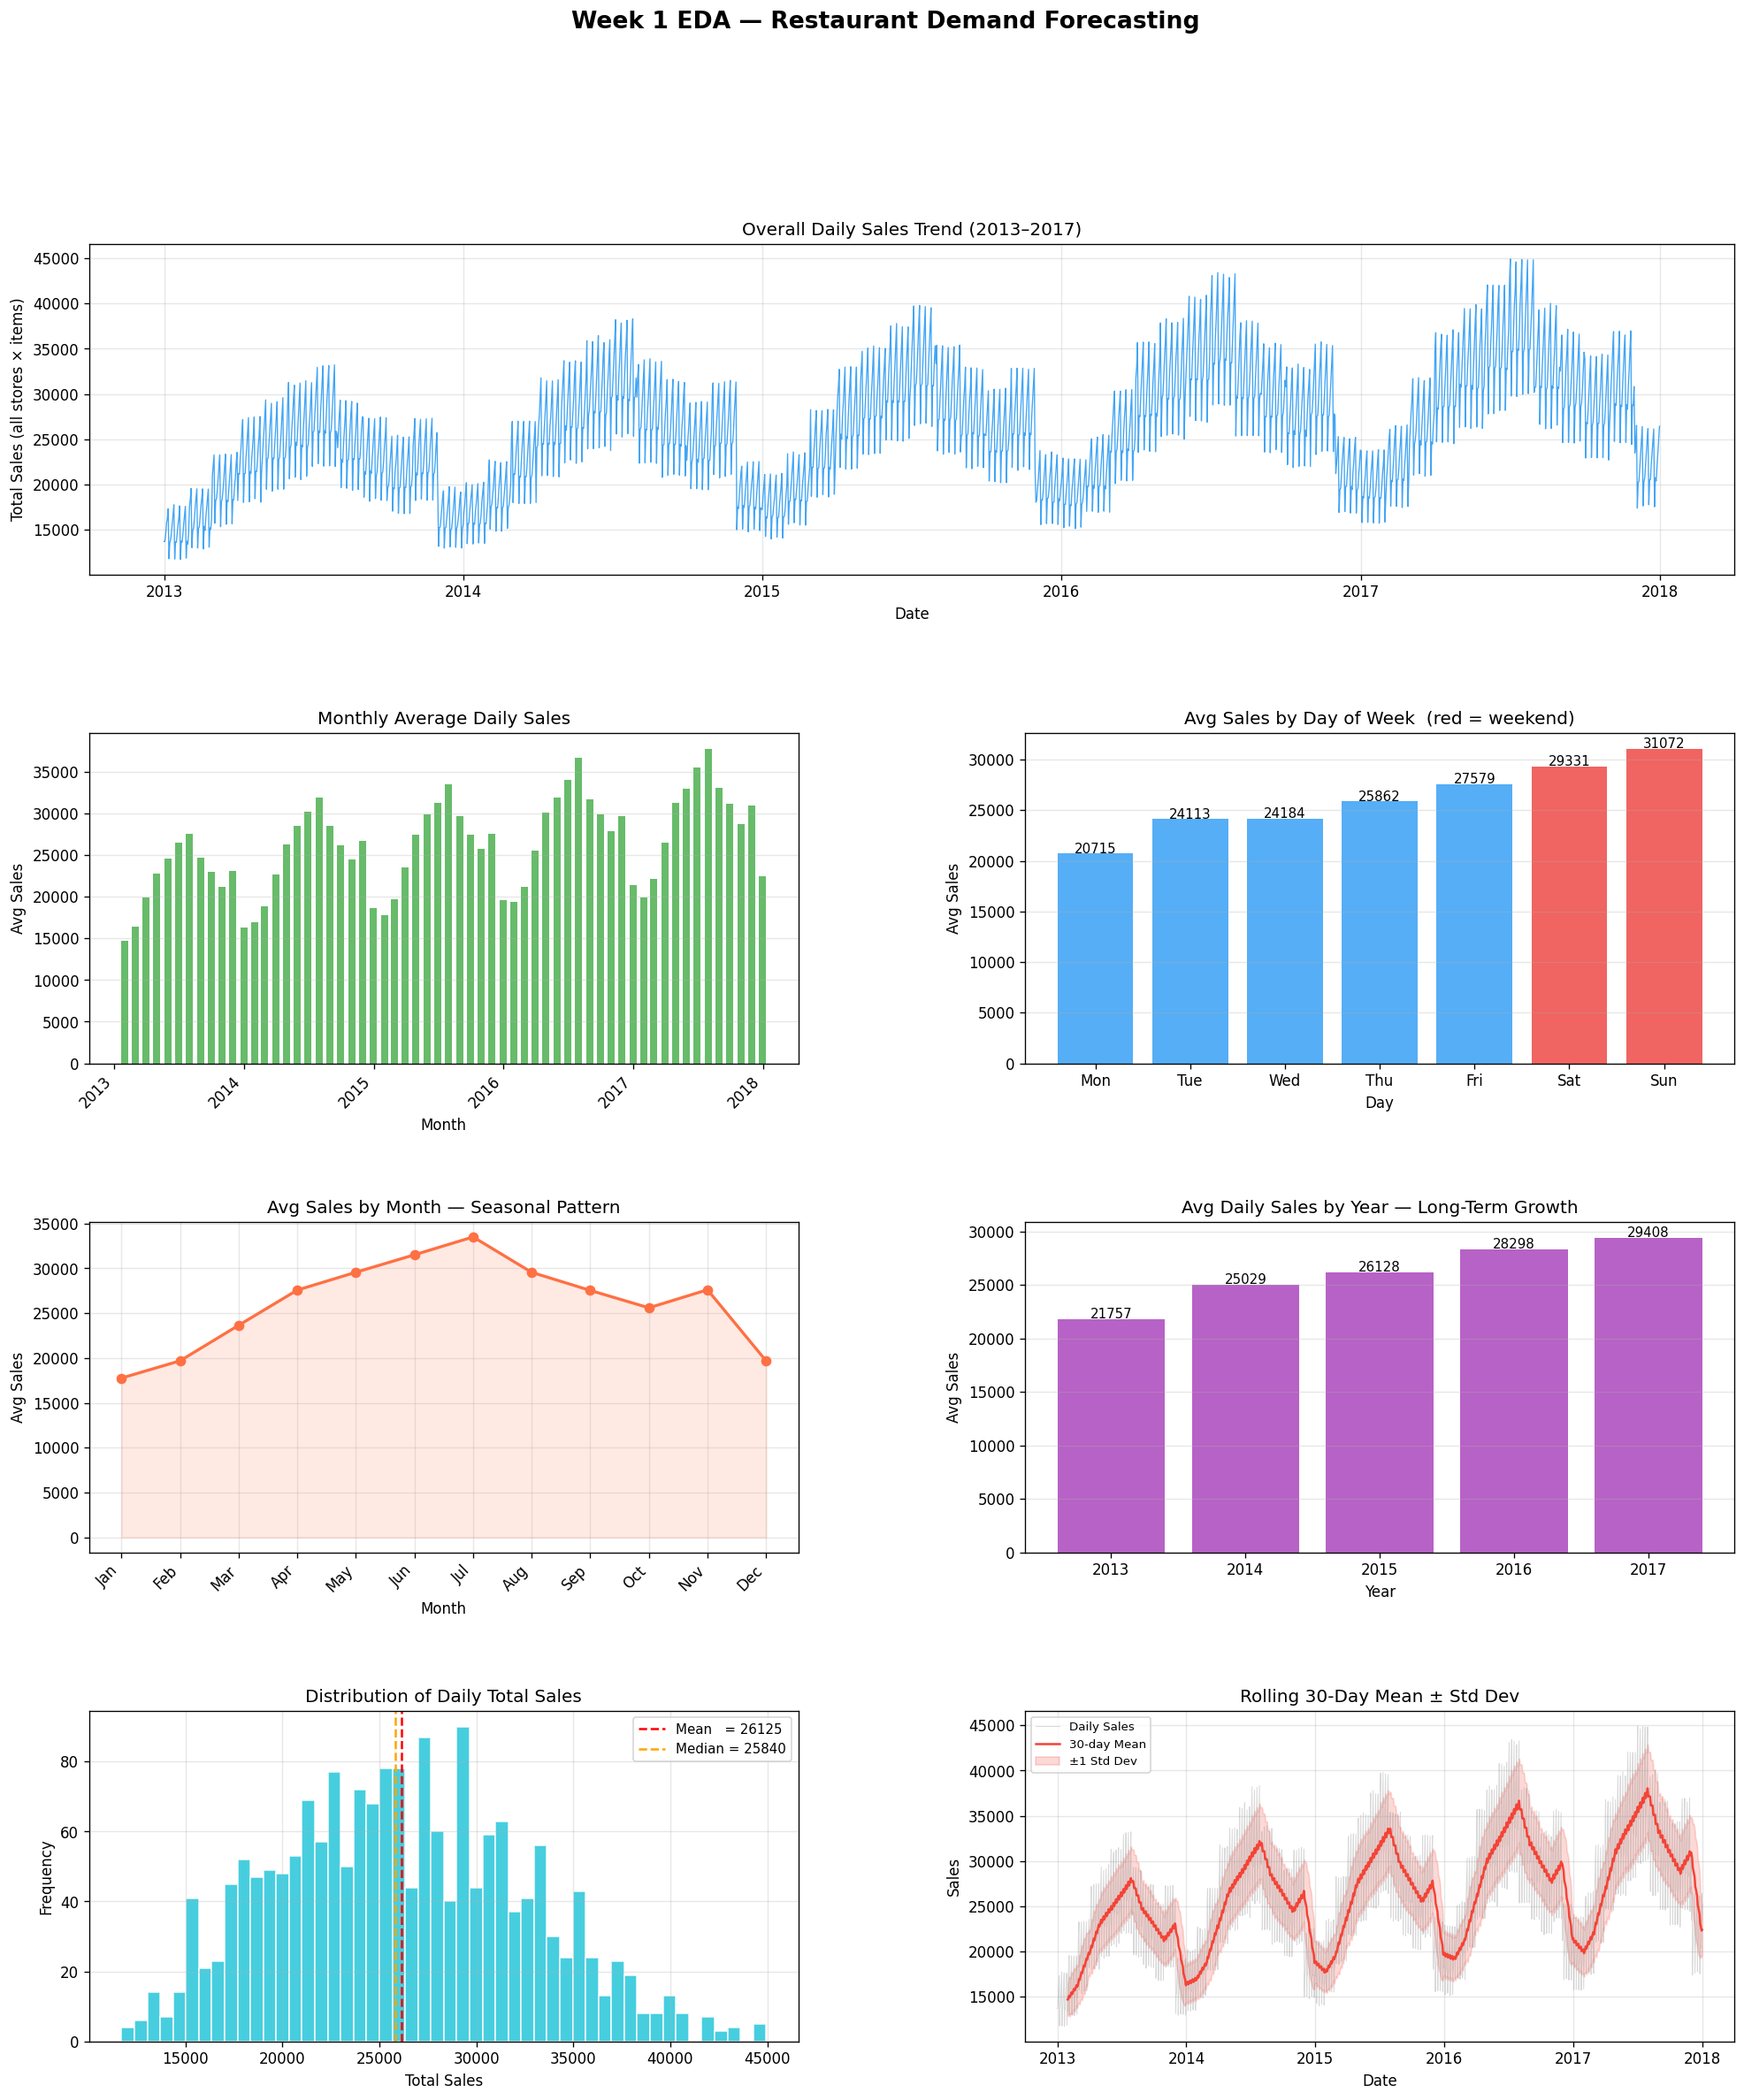

In [6]:
fig = plt.figure(figsize=(20, 22))
fig.suptitle('Week 1 EDA — Restaurant Demand Forecasting',
             fontsize=16, fontweight='bold', y=0.98)
gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.48, wspace=0.32)

# --- Panel 1: Full time-series trend ---
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(daily.index, daily.values, color='#2196F3', linewidth=0.8, alpha=0.85)
ax1.set_title('Overall Daily Sales Trend (2013–2017)', fontsize=12)
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Sales (all stores × items)')
ax1.grid(alpha=0.3)

# --- Panel 2: Monthly average ---
monthly = daily.resample('ME').mean()
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(monthly.index, monthly.values, color='#4CAF50', width=20, alpha=0.85)
ax2.set_title('Monthly Average Daily Sales', fontsize=12)
ax2.set_xlabel('Month'); ax2.set_ylabel('Avg Sales')
ax2.grid(axis='y', alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Panel 3: Day-of-week pattern ---
dow_avg    = daily.groupby(daily.index.dayofweek).mean()
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
colors     = ['#EF5350' if i >= 5 else '#42A5F5' for i in range(7)]
ax3 = fig.add_subplot(gs[1, 1])
bars = ax3.bar(dow_labels, dow_avg.values, color=colors, alpha=0.9)
ax3.set_title('Avg Sales by Day of Week  (red = weekend)', fontsize=12)
ax3.set_xlabel('Day'); ax3.set_ylabel('Avg Sales')
ax3.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, dow_avg.values):
    ax3.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50, f'{val:.0f}', ha='center', fontsize=9)

# --- Panel 4: Monthly seasonality ---
month_avg    = daily.groupby(daily.index.month).mean()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(month_labels, month_avg.values,
         marker='o', color='#FF7043', linewidth=2, markersize=6)
ax4.fill_between(month_labels, month_avg.values, alpha=0.15, color='#FF7043')
ax4.set_title('Avg Sales by Month — Seasonal Pattern', fontsize=12)
ax4.set_xlabel('Month'); ax4.set_ylabel('Avg Sales')
ax4.grid(alpha=0.3)
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45, ha='right')

# --- Panel 5: Yearly growth ---
year_avg = daily.groupby(daily.index.year).mean()
ax5 = fig.add_subplot(gs[2, 1])
ax5.bar(year_avg.index.astype(str), year_avg.values, color='#AB47BC', alpha=0.85)
for i, (yr, val) in enumerate(zip(year_avg.index, year_avg.values)):
    ax5.text(i, val + 100, f'{val:.0f}', ha='center', fontsize=9)
ax5.set_title('Avg Daily Sales by Year — Long-Term Growth', fontsize=12)
ax5.set_xlabel('Year'); ax5.set_ylabel('Avg Sales')
ax5.grid(axis='y', alpha=0.3)

# --- Panel 6: Sales distribution ---
ax6 = fig.add_subplot(gs[3, 0])
ax6.hist(daily.values, bins=50, color='#26C6DA', edgecolor='white', alpha=0.85)
ax6.axvline(daily.mean(), color='red', linestyle='--',
            linewidth=1.5, label=f'Mean   = {daily.mean():.0f}')
ax6.axvline(daily.median(), color='orange', linestyle='--',
            linewidth=1.5, label=f'Median = {daily.median():.0f}')
ax6.set_title('Distribution of Daily Total Sales', fontsize=12)
ax6.set_xlabel('Total Sales'); ax6.set_ylabel('Frequency')
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

# --- Panel 7: Rolling 30-day mean ± std ---
rm = daily.rolling(30).mean()
rs = daily.rolling(30).std()
ax7 = fig.add_subplot(gs[3, 1])
ax7.plot(daily.index, daily.values,
         alpha=0.3, color='gray', linewidth=0.6, label='Daily Sales')
ax7.plot(daily.index, rm, color='#F44336', linewidth=1.5, label='30-day Mean')
ax7.fill_between(daily.index, rm - rs, rm + rs,
                 alpha=0.2, color='#F44336', label='±1 Std Dev')
ax7.set_title('Rolling 30-Day Mean ± Std Dev', fontsize=12)
ax7.set_xlabel('Date'); ax7.set_ylabel('Sales')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

plt.show()

## 1.4 Seasonal Decomposition
Splits the series into **Trend + Seasonality + Residual**

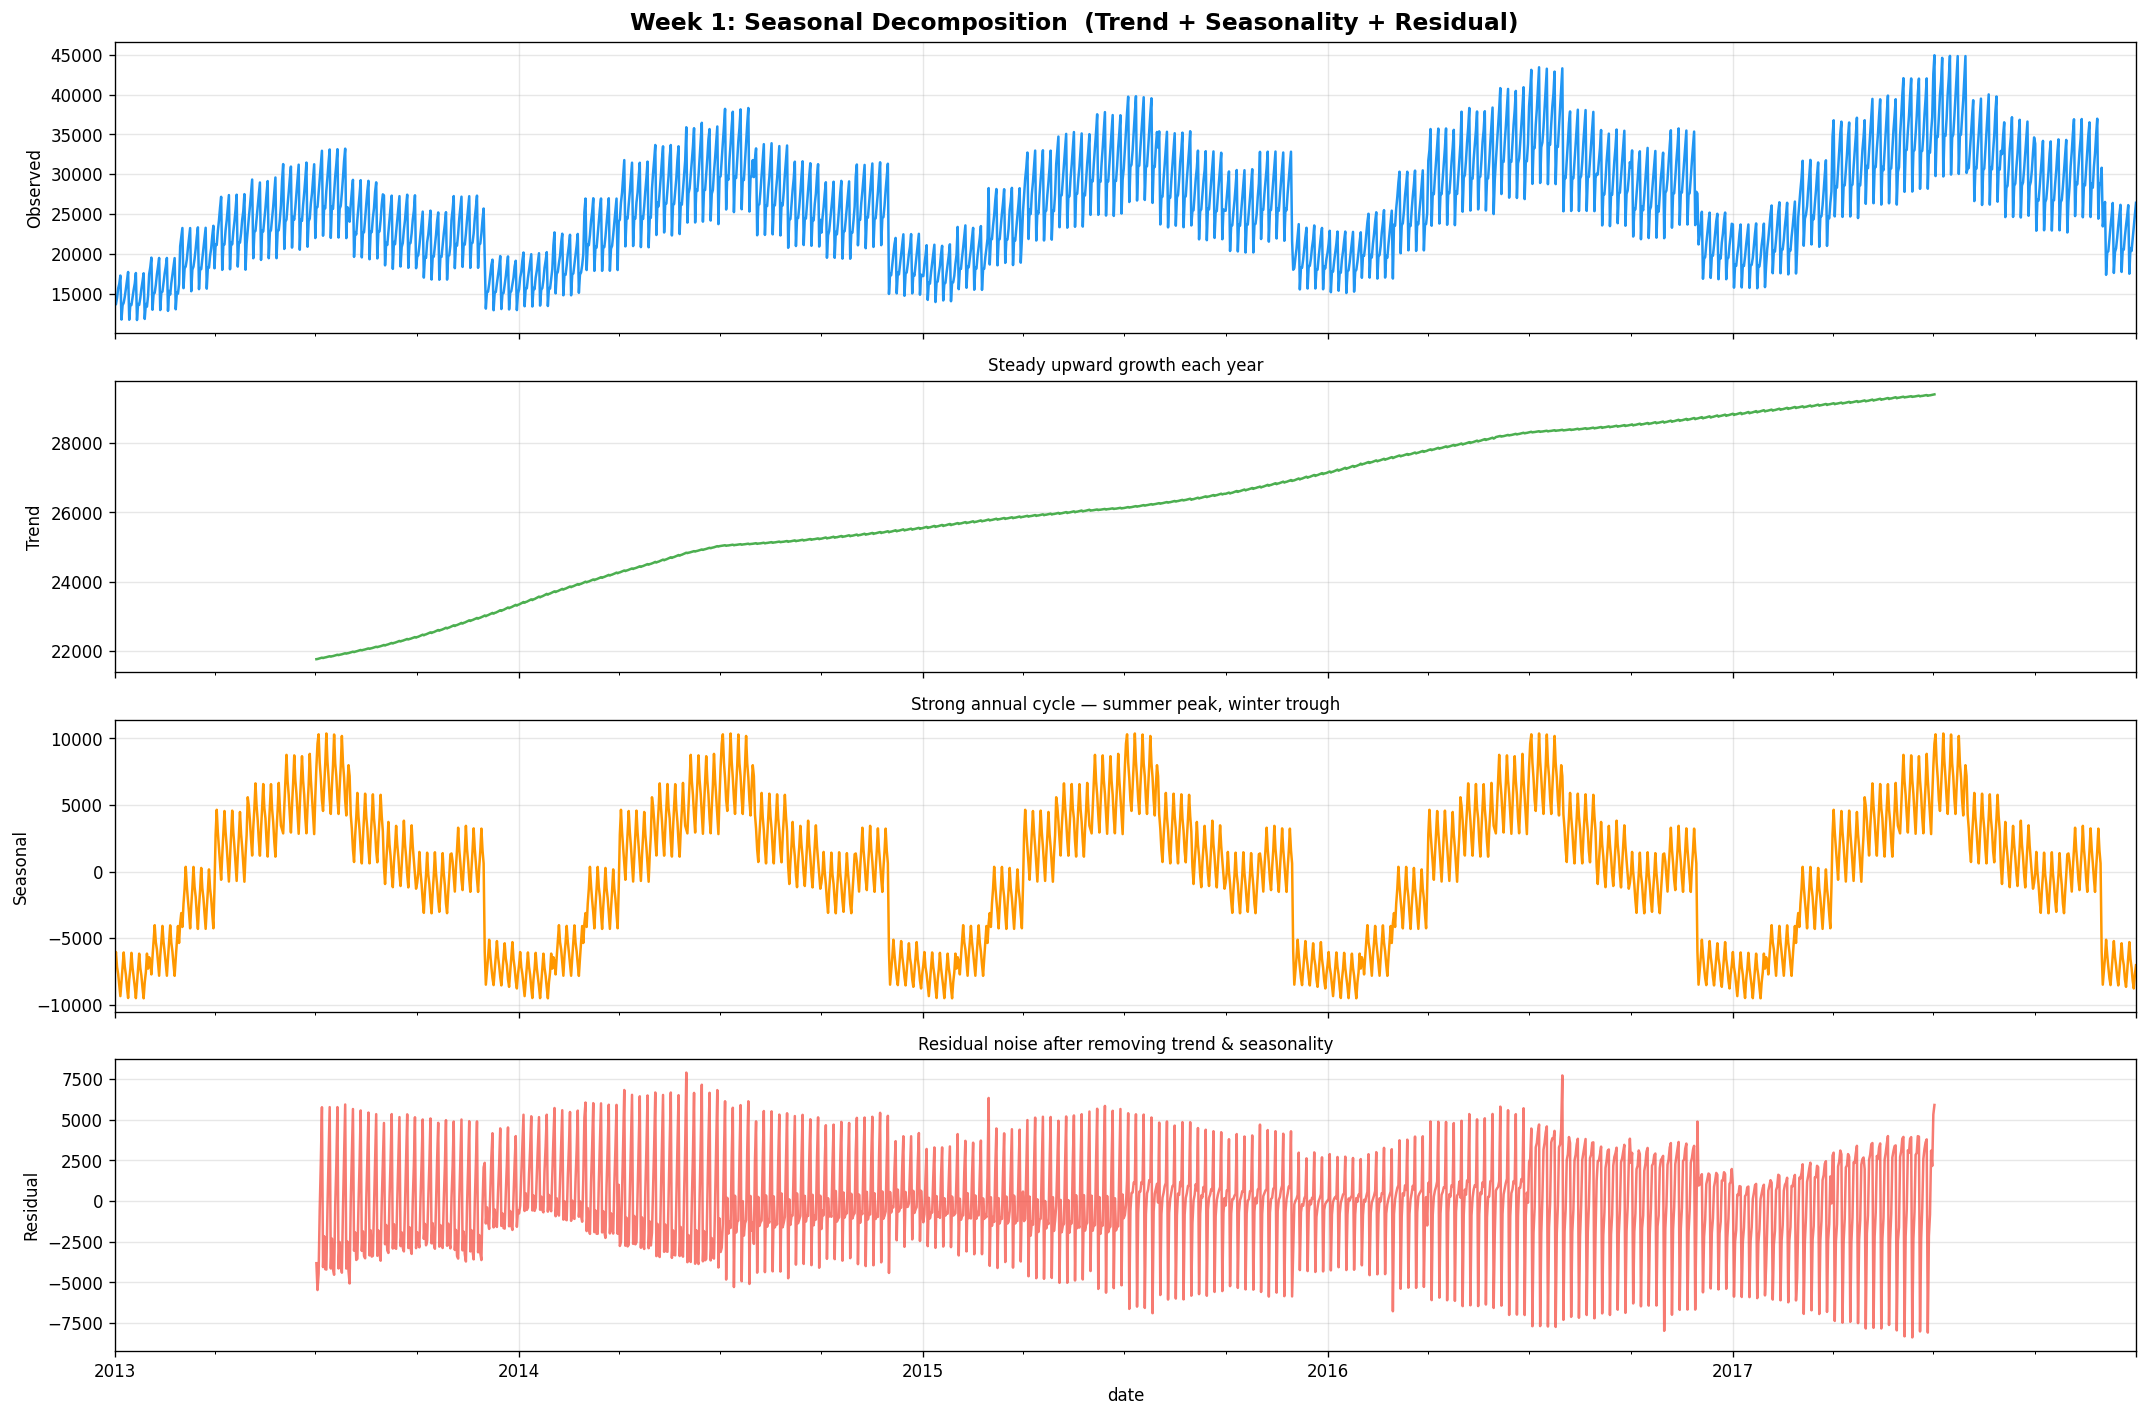

In [7]:
decomp = seasonal_decompose(daily, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(18, 12), sharex=True)
fig.suptitle('Week 1: Seasonal Decomposition  (Trend + Seasonality + Residual)',
             fontsize=14, fontweight='bold')

decomp.observed.plot(ax=axes[0], color='#2196F3')
axes[0].set_ylabel('Observed'); axes[0].grid(alpha=0.3)

decomp.trend.plot(ax=axes[1], color='#4CAF50')
axes[1].set_ylabel('Trend')
axes[1].set_title('Steady upward growth each year', fontsize=10)
axes[1].grid(alpha=0.3)

decomp.seasonal.plot(ax=axes[2], color='#FF9800')
axes[2].set_ylabel('Seasonal')
axes[2].set_title('Strong annual cycle — summer peak, winter trough', fontsize=10)
axes[2].grid(alpha=0.3)

decomp.resid.plot(ax=axes[3], color='#F44336', alpha=0.7)
axes[3].set_ylabel('Residual')
axes[3].set_title('Residual noise after removing trend & seasonality', fontsize=10)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 1.5 Autocorrelation Analysis — ACF & PACF
Guides which **lag values** to use as features in Week 2

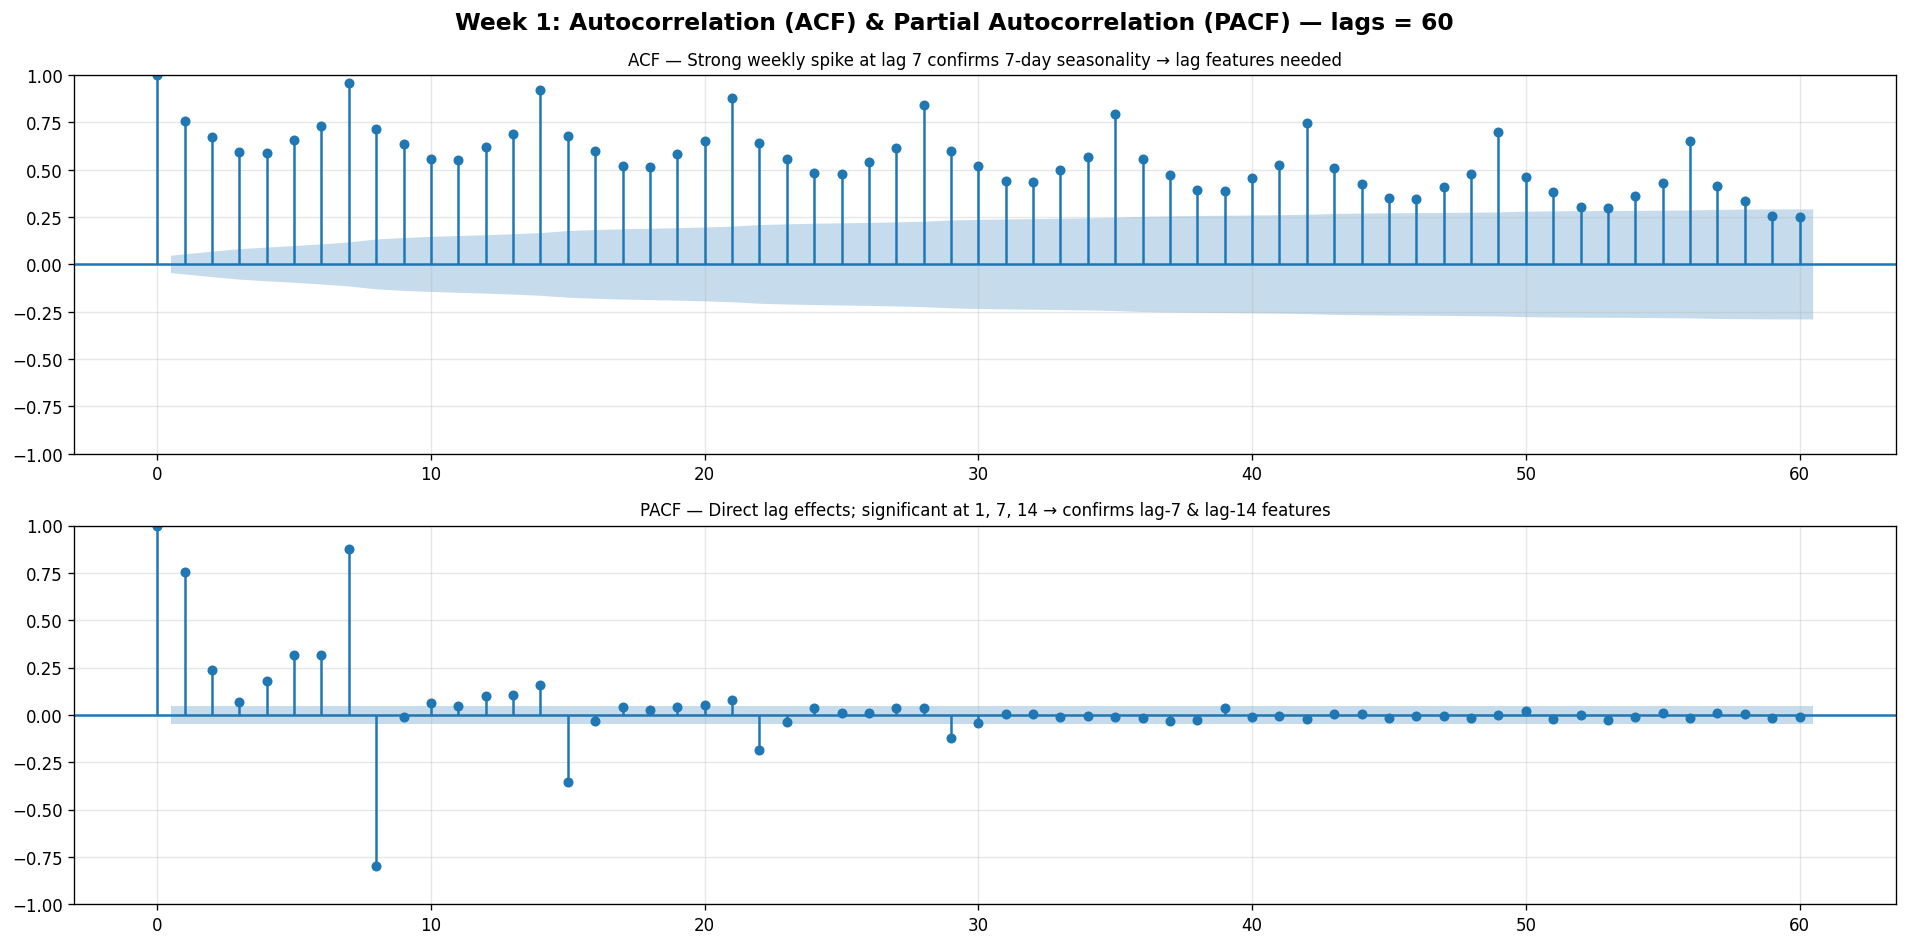

In [8]:
fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(16, 8))
fig.suptitle('Week 1: Autocorrelation (ACF) & Partial Autocorrelation (PACF) — lags = 60',
             fontsize=14, fontweight='bold')

plot_acf(daily.dropna(), lags=60, ax=ax_acf)
ax_acf.set_title(
    'ACF — Strong weekly spike at lag 7 confirms 7-day seasonality → lag features needed',
    fontsize=10)
ax_acf.grid(alpha=0.3)

plot_pacf(daily.dropna(), lags=60, ax=ax_pacf, method='ywm')
ax_pacf.set_title(
    'PACF — Direct lag effects; significant at 1, 7, 14 → confirms lag-7 & lag-14 features',
    fontsize=10)
ax_pacf.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# 🔧 WEEK 2 — Advanced Feature Engineering & Train/Val Split

## 2.1 Re-load & Sort
Sort by `(store, item, date)` so grouped shifts work correctly

In [9]:
df = train.sort_values(['store', 'item', 'date']).reset_index(drop=True)
print(f'Working dataframe : {df.shape}  (store × item × date rows)')
df.head()

Working dataframe : (913000, 4)  (store × item × date rows)


,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


## 2.2 Calendar / Chronological Features

In [10]:
# Raw calendar components
df['day_of_week']      = df['date'].dt.dayofweek           # 0=Mon … 6=Sun
df['day_of_month']     = df['date'].dt.day                 # 1–31
df['day_of_year']      = df['date'].dt.day_of_year         # 1–366
df['week_of_year']     = df['date'].dt.isocalendar().week.astype(int)  # 1–53
df['month']            = df['date'].dt.month               # 1–12
df['quarter']          = df['date'].dt.quarter             # 1–4
df['year']             = df['date'].dt.year                # 2013–2017

# Binary flags
df['is_weekend']       = (df['day_of_week'] >= 5).astype(int)
df['is_month_start']   = df['date'].dt.is_month_start.astype(int)
df['is_month_end']     = df['date'].dt.is_month_end.astype(int)
df['is_quarter_start'] = df['date'].dt.is_quarter_start.astype(int)

# Cyclical (sin/cos) encoding
# Prevents model treating Dec (12) and Jan (1) as far apart
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Holiday flag — high-demand days where normal patterns break down
HOLIDAYS = {
    '01-01',  # New Year's Day
    '02-14',  # Valentine's Day
    '07-04',  # Independence Day
    '10-31',  # Halloween
    '11-25',  # Thanksgiving (approx)
    '12-24',  # Christmas Eve
    '12-25',  # Christmas Day
    '12-31',  # New Year's Eve
}
df['is_holiday'] = df['date'].dt.strftime('%m-%d').isin(HOLIDAYS).astype(int)

calendar_feats = ['day_of_week','day_of_month','day_of_year','week_of_year',
                  'month','quarter','year','is_weekend','is_month_start',
                  'is_month_end','is_quarter_start','dow_sin','dow_cos',
                  'month_sin','month_cos','is_holiday']
print(f'✓ Calendar features built : {len(calendar_feats)}')
df[calendar_feats].head(3)

✓ Calendar features built : 16


,day_of_week,day_of_month,day_of_year,week_of_year,month,quarter,year,is_weekend,is_month_start,is_month_end,is_quarter_start,dow_sin,dow_cos,month_sin,month_cos,is_holiday
0,1,1,1,1,1,1,2013,0,1,0,1,0.781831,0.623490,0.5,0.866025,1
1,2,2,2,1,1,1,2013,0,0,0,0,0.974928,-0.222521,0.5,0.866025,0
2,3,3,3,1,1,1,2013,0,0,0,0,0.433884,-0.900969,0.5,0.866025,0


## 2.3 Lag Features
Grouped by `(store, item)` — **no leakage across entities**

In [11]:
# ACF/PACF from Week 1 showed strong autocorrelations at lags 1,2,3,7,14,21,28
grp = df.groupby(['store', 'item'])['sales']

LAG_DAYS = [1, 2, 3, 7, 14, 21, 28]
for lag in LAG_DAYS:
    df[f'lag_{lag}d'] = grp.shift(lag)

print(f'✓ Lag features built — lags: {LAG_DAYS}')
df[['store','item','date','sales'] + [f'lag_{l}d' for l in LAG_DAYS]].head(10)

✓ Lag features built — lags: [1, 2, 3, 7, 14, 21, 28]


,store,item,date,sales,lag_1d,lag_2d,lag_3d,lag_7d,lag_14d,lag_21d,lag_28d
0,1,1,2013-01-01,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1,2013-01-02,11,13.0,NaN,NaN,NaN,NaN,NaN,NaN
2,1,1,2013-01-03,14,11.0,13.0,NaN,NaN,NaN,NaN,NaN
3,1,1,2013-01-04,13,14.0,11.0,13.0,NaN,NaN,NaN,NaN
4,1,1,2013-01-05,10,13.0,14.0,11.0,NaN,NaN,NaN,NaN
5,1,1,2013-01-06,12,10.0,13.0,14.0,NaN,NaN,NaN,NaN
6,1,1,2013-01-07,10,12.0,10.0,13.0,NaN,NaN,NaN,NaN
7,1,1,2013-01-08,9,10.0,12.0,10.0,13.0,NaN,NaN,NaN
8,1,1,2013-01-09,12,9.0,10.0,12.0,11.0,NaN,NaN,NaN
9,1,1,2013-01-10,9,12.0,9.0,10.0,14.0,NaN,NaN,NaN


## 2.4 Rolling Window Statistics
Shifted by **1 day** to avoid same-day leakage

In [12]:
WINDOWS = [7, 14, 30]
for w in WINDOWS:
    df[f'rolling_mean_{w}d'] = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).mean())
    df[f'rolling_std_{w}d']  = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).std())
    df[f'rolling_max_{w}d']  = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).max())
    df[f'rolling_min_{w}d']  = grp.transform(
        lambda x: x.shift(1).rolling(w, min_periods=1).min())

print(f'✓ Rolling window stats built — windows: {WINDOWS}d  (mean, std, max, min each)')

roll_cols = [f'rolling_mean_{w}d' for w in WINDOWS]
df[['store','item','date','sales'] + roll_cols].head(5)

✓ Rolling window stats built — windows: [7, 14, 30]d  (mean, std, max, min each)


,store,item,date,sales,rolling_mean_7d,rolling_mean_14d,rolling_mean_30d
0,1,1,2013-01-01,13,NaN,NaN,NaN
1,1,1,2013-01-02,11,13.000000,13.000000,13.000000
2,1,1,2013-01-03,14,12.000000,12.000000,12.000000
3,1,1,2013-01-04,13,12.666667,12.666667,12.666667
4,1,1,2013-01-05,10,12.750000,12.750000,12.750000


## 2.5 Expanding Mean
Cumulative historical average per `store × item`

In [13]:
df['expanding_mean'] = grp.transform(
    lambda x: x.shift(1).expanding().mean())

print('✓ Expanding mean built')
df[['store','item','date','sales','expanding_mean']].head(5)

✓ Expanding mean built


,store,item,date,sales,expanding_mean
0,1,1,2013-01-01,13,NaN
1,1,1,2013-01-02,11,13.000000
2,1,1,2013-01-03,14,12.000000
3,1,1,2013-01-04,13,12.666667
4,1,1,2013-01-05,10,12.750000


## 2.6 Drop NaN Warm-up Rows

In [14]:
rows_before = len(df)
df_clean    = df.dropna().reset_index(drop=True)

feature_cols = [c for c in df_clean.columns if c not in ['date', 'sales']]

print(f'Rows before lag-drop : {rows_before:,}')
print(f'Rows after  lag-drop : {len(df_clean):,}  '
      f'(removed {rows_before - len(df_clean):,} warm-up rows)')
print(f'\nTotal features built : {len(feature_cols)}')
print('\nFeature list:')
for i in range(0, len(feature_cols), 6):
    print(f'  {feature_cols[i:i+6]}')

Rows before lag-drop : 913,000
Rows after  lag-drop : 899,000  (removed 14,000 warm-up rows)

Total features built : 38

Feature list:
  ['store', 'item', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year']
  ['month', 'quarter', 'year', 'is_weekend', 'is_month_start', 'is_month_end']
  ['is_quarter_start', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_holiday']
  ['lag_1d', 'lag_2d', 'lag_3d', 'lag_7d', 'lag_14d', 'lag_21d']
  ['lag_28d', 'rolling_mean_7d', 'rolling_std_7d', 'rolling_max_7d', 'rolling_min_7d', 'rolling_mean_14d']
  ['rolling_std_14d', 'rolling_max_14d', 'rolling_min_14d', 'rolling_mean_30d', 'rolling_std_30d', 'rolling_max_30d']
  ['rolling_min_30d', 'expanding_mean']


## 2.7 Sequential Train / Validation Split
>

In [15]:
# Train  → 2013-01-29 to 2016-12-31  (~80%)
# Validate → 2017-01-01 to 2017-12-31  (~20%)
SPLIT_DATE = pd.Timestamp('2017-01-01')

df_train = df_clean[df_clean['date'] <  SPLIT_DATE].copy()
df_val   = df_clean[df_clean['date'] >= SPLIT_DATE].copy()

X_train = df_train[feature_cols];  y_train = df_train['sales']
X_val   = df_val[feature_cols];    y_val   = df_val['sales']

print(f'Train : {df_train["date"].min().date()} → {df_train["date"].max().date()}  '
      f'({len(df_train):,} rows)')
print(f'Val   : {df_val["date"].min().date()} → {df_val["date"].max().date()}  '
      f'({len(df_val):,} rows)')
print(f'\nX_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_val   : {X_val.shape}   y_val   : {y_val.shape}')

Train : 2013-01-29 → 2016-12-31  (716,500 rows)
Val   : 2017-01-01 → 2017-12-31  (182,500 rows)

X_train : (716500, 38)   y_train : (716500,)
X_val   : (182500, 38)   y_val   : (182500,)


## 2.8 Plot — Sequential Train / Validation Split

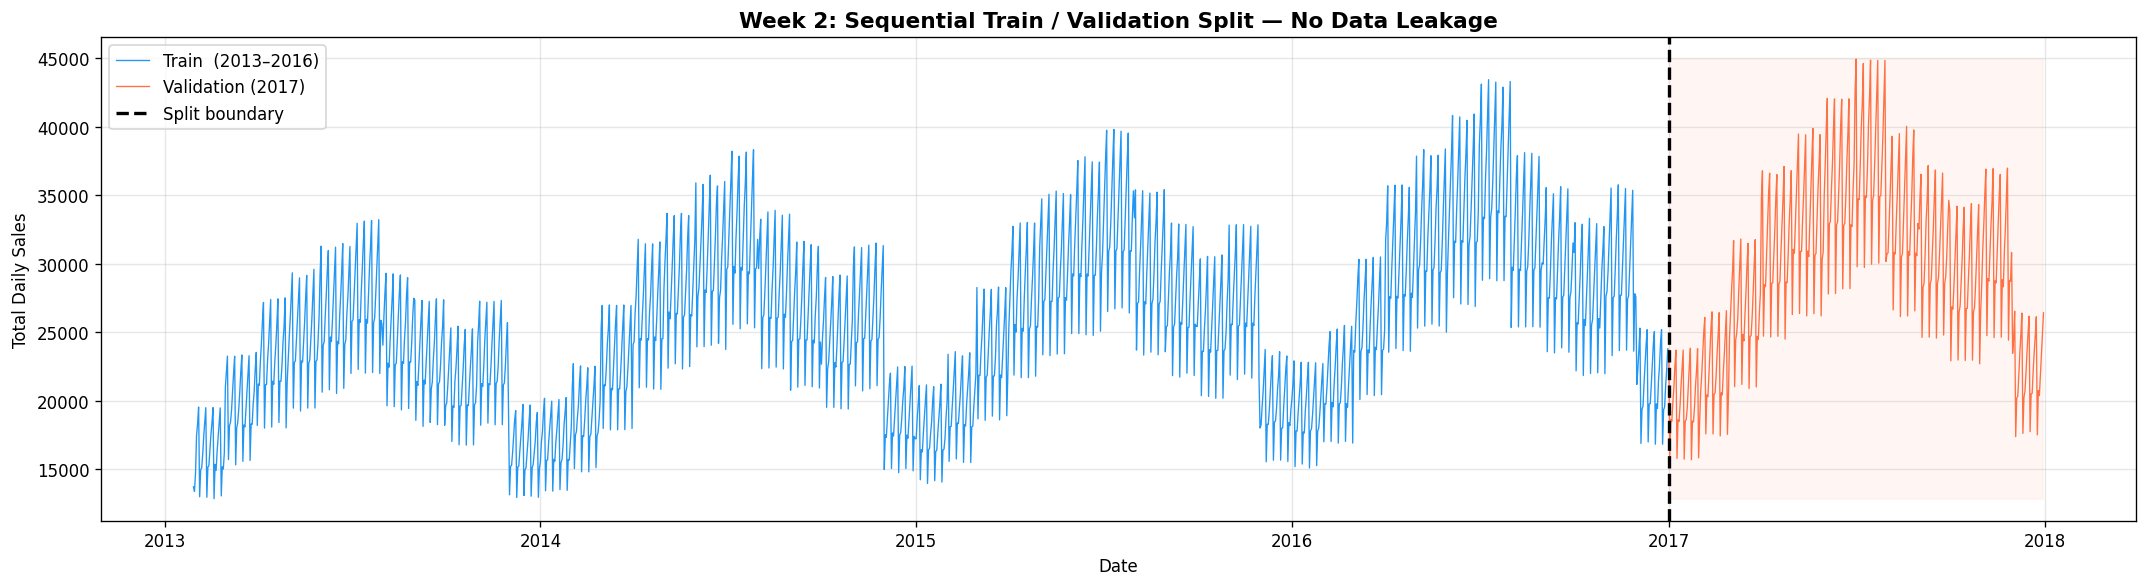

In [16]:
daily_tr = df_train.groupby('date')['sales'].sum()
daily_va = df_val.groupby('date')['sales'].sum()

fig, ax = plt.subplots(figsize=(18, 5))
ax.plot(daily_tr.index, daily_tr.values,
        color='#2196F3', linewidth=0.8, label='Train  (2013–2016)')
ax.plot(daily_va.index, daily_va.values,
        color='#FF7043', linewidth=0.8, label='Validation (2017)')
ax.axvline(SPLIT_DATE, color='black', linestyle='--',
           linewidth=2, label='Split boundary')
ax.fill_betweenx(
    [min(daily_tr.min(), daily_va.min()),
     max(daily_tr.max(), daily_va.max())],
    SPLIT_DATE, daily_va.index.max(),
    alpha=0.06, color='#FF7043'
)
ax.set_title('Week 2: Sequential Train / Validation Split — No Data Leakage',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date'); ax.set_ylabel('Total Daily Sales')
ax.legend(fontsize=10); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 2.9 Feature Correlation Heatmap

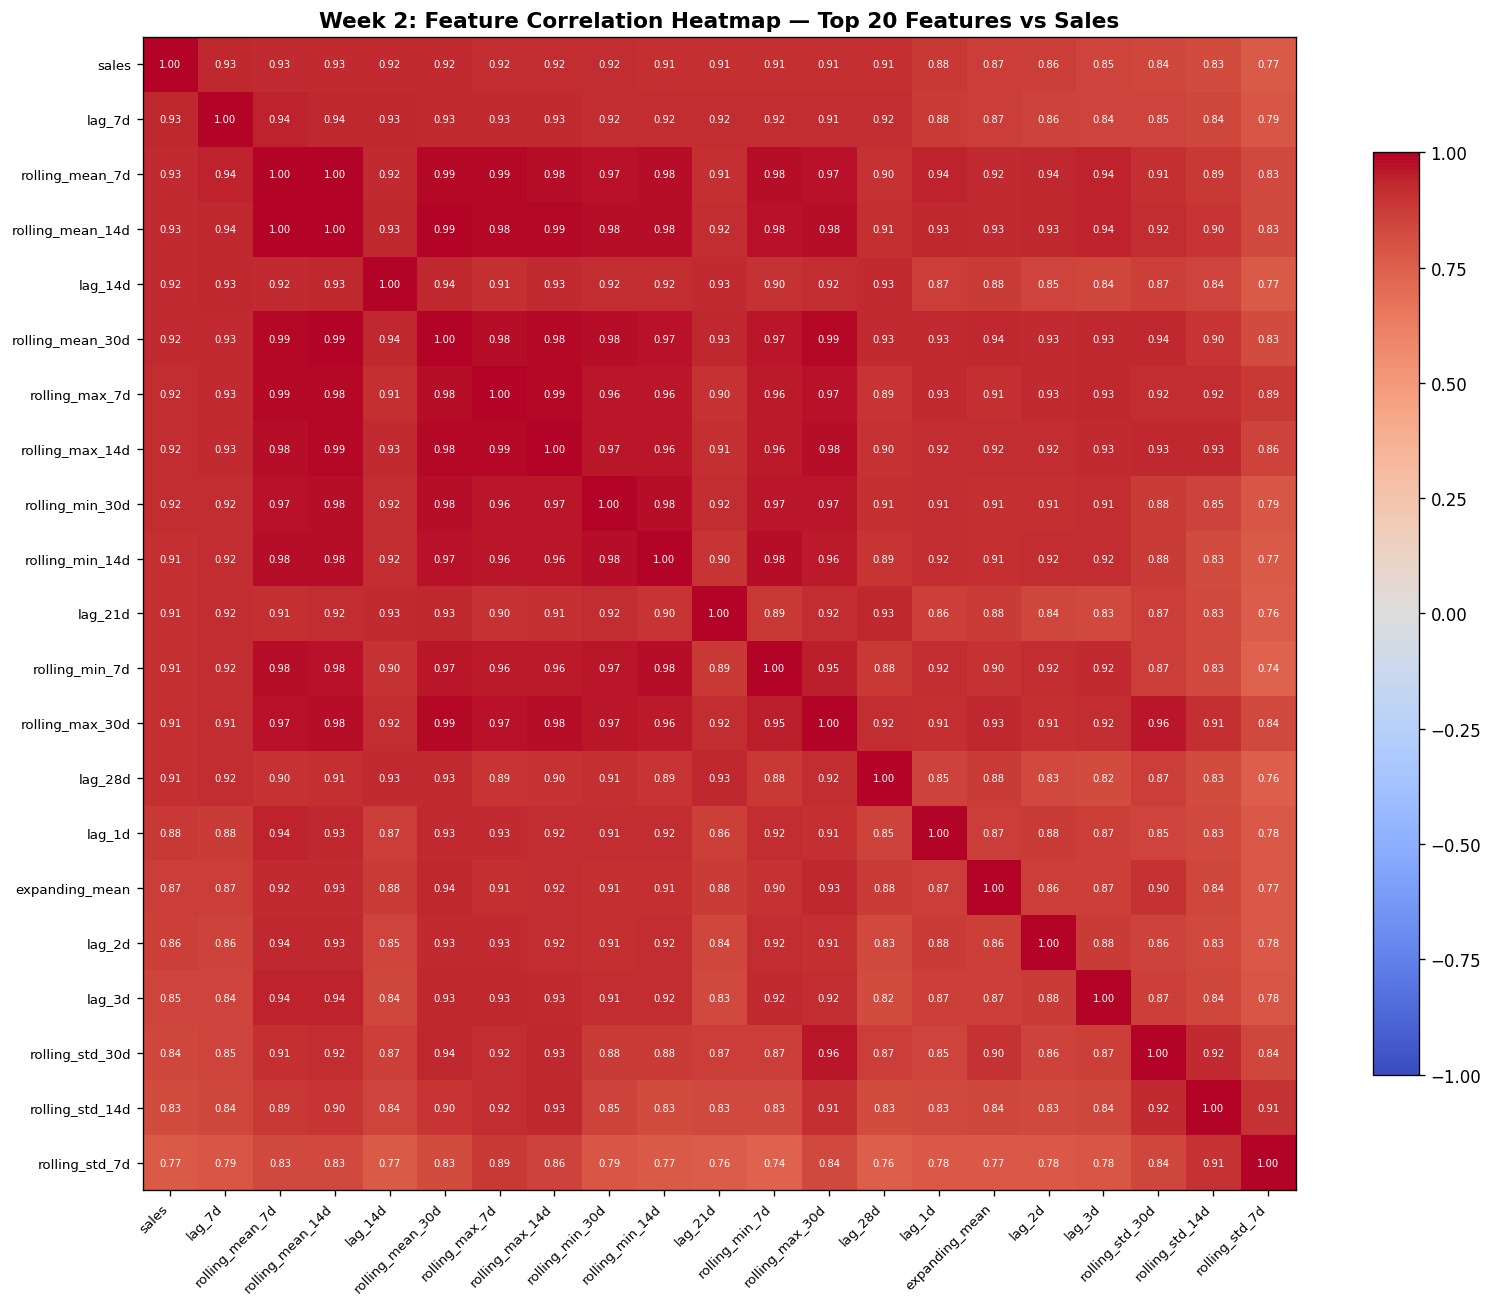

In [17]:
sample    = df_clean.sample(5000, random_state=42)
num_cols  = ['sales'] + [c for c in feature_cols
                         if df_clean[c].dtype in [np.float64, np.int64]]
top_feats = (sample[num_cols].corr()['sales']
             .drop('sales').abs().nlargest(20).index.tolist())
corr_top  = sample[['sales'] + top_feats].corr()

fig, ax = plt.subplots(figsize=(14, 11))
im = ax.imshow(corr_top.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_top.columns)))
ax.set_yticks(range(len(corr_top.columns)))
ax.set_xticklabels(corr_top.columns, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(corr_top.columns, fontsize=8)
for i in range(len(corr_top)):
    for j in range(len(corr_top)):
        v = corr_top.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                fontsize=6, color='black' if abs(v) < 0.7 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Week 2: Feature Correlation Heatmap — Top 20 Features vs Sales',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.10 Quick Random Forest Baseline + Feature Importance

In [18]:
print('Training RF baseline (50k sample, 100 trees, max_depth=8)...')
sample_tr = df_train.sample(min(50_000, len(df_train)), random_state=42)

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=8,
    min_samples_leaf=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(sample_tr[feature_cols], sample_tr['sales'])

val_pred = rf.predict(X_val)
mae      = mean_absolute_error(y_val, val_pred)
rmse     = np.sqrt(mean_squared_error(y_val, val_pred))

print(f'\n── Quick RF Baseline Results ──')
print(f'   MAE  : {mae:.3f} units')
print(f'   RMSE : {rmse:.3f} units')
print('   ➜ Week 3/4: full XGBoost on 716k rows + Prophet will improve these significantly')

Training RF baseline (50k sample, 100 trees, max_depth=8)...

── Quick RF Baseline Results ──
   MAE  : 6.706 units
   RMSE : 8.814 units
   ➜ Week 3/4: full XGBoost on 716k rows + Prophet will improve these significantly


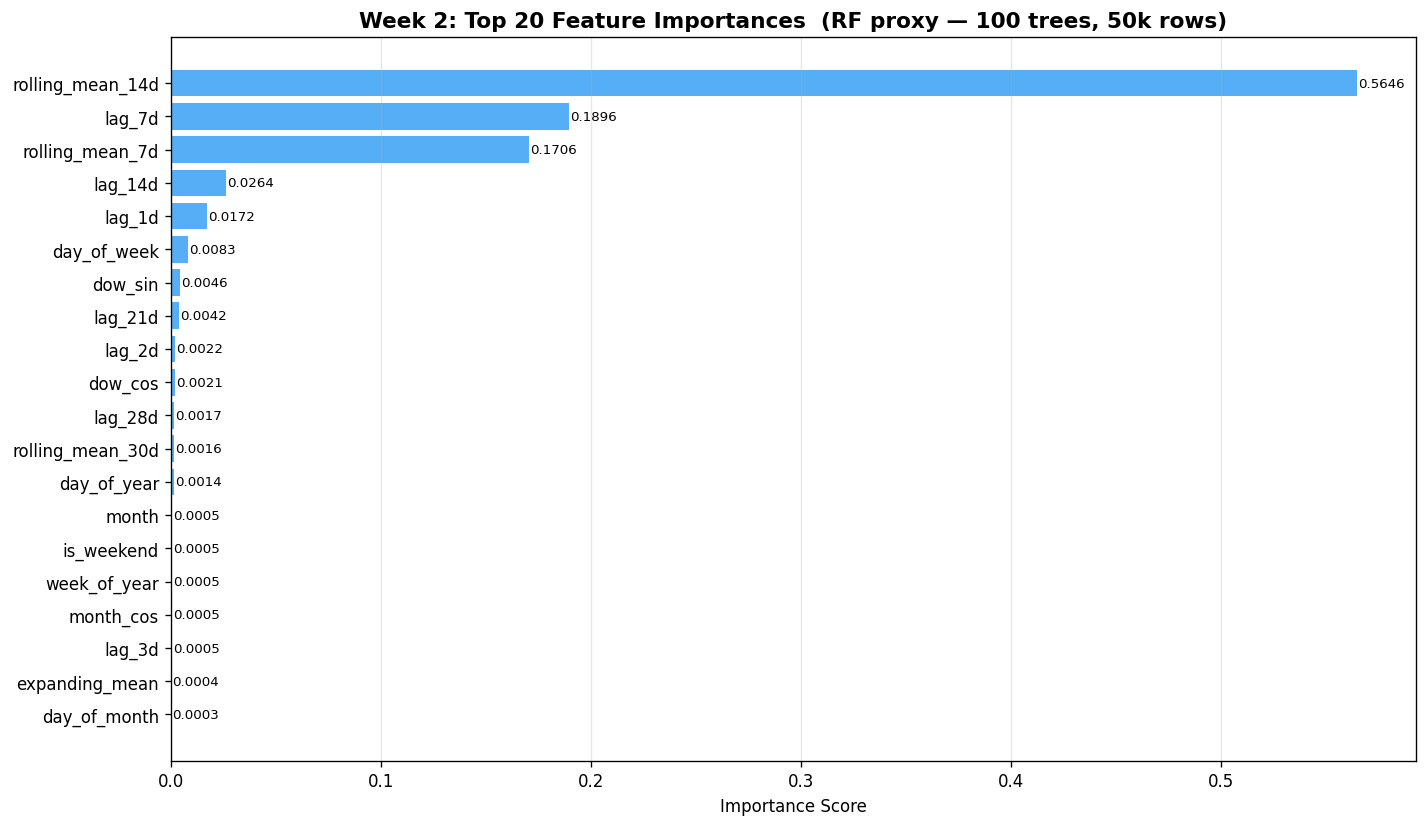

In [19]:
importances = (
    pd.Series(rf.feature_importances_, index=feature_cols)
    .sort_values(ascending=False)
)
top_imp = importances.head(20)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_imp.index[::-1], top_imp.values[::-1],
               color='#42A5F5', alpha=0.9)
ax.set_title('Week 2: Top 20 Feature Importances  (RF proxy — 100 trees, 50k rows)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
ax.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, top_imp.values[::-1]):
    ax.text(bar.get_width() + 0.0005,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 2.11 Feature Summary Table

In [20]:
summary = pd.DataFrame({
    'Category': [
        'Calendar (raw)', 'Binary flags', 'Cyclical encoding',
        'Holiday flag', 'Lag features', 'Rolling stats', 'Expanding mean'
    ],
    'Count': [7, 4, 4, 1, 7, 12, 1],
    'Features': [
        'day_of_week, day_of_month, day_of_year, week_of_year, month, quarter, year',
        'is_weekend, is_month_start, is_month_end, is_quarter_start',
        'dow_sin, dow_cos, month_sin, month_cos',
        'is_holiday  (8 major holidays)',
        'lag_1d, lag_2d, lag_3d, lag_7d, lag_14d, lag_21d, lag_28d',
        'rolling_mean/std/max/min × 7d, 14d, 30d',
        'expanding_mean'
    ]
})

print(f'TOTAL : {summary["Count"].sum()} features  +  store  +  item  =  '
      f'{summary["Count"].sum() + 2} model inputs')
summary

TOTAL : 36 features  +  store  +  item  =  38 model inputs


,Category,Count,Features
0,Calendar (raw),7,"day_of_week, day_of_month, day_of_year, week_o..."
1,Binary flags,4,"is_weekend, is_month_start, is_month_end, is_q..."
2,Cyclical encoding,4,"dow_sin, dow_cos, month_sin, month_cos"
3,Holiday flag,1,is_holiday (8 major holidays)
4,Lag features,7,"lag_1d, lag_2d, lag_3d, lag_7d, lag_14d, lag_2..."
5,Rolling stats,12,"rolling_mean/std/max/min × 7d, 14d, 30d"
6,Expanding mean,1,expanding_mean


---
## ✅ Week 1 & 2 Complete

| Output | Description |
|--------|-------------|
| `df_clean` | Full feature-engineered DataFrame (899k rows × 38 cols) |
| `df_train` / `X_train` / `y_train` | Training split 2013–2016 (~716k rows) |
| `df_val` / `X_val` / `y_val` | Validation split 2017 (~182k rows) |

**Next → Week 3:** Train full XGBoost + Prophet models on `X_train` / `y_train` and evaluate on `X_val` / `y_val`